# 03 — Modelli Baseline Classici

Questo notebook implementa il training e la valutazione dei modelli baseline classici:
1. **TF-IDF + Linear SVM**
2. **TF-IDF + XGBoost**

Entrambi i modelli utilizzano come feature:
- La rappresentazione Bag-of-Words pesata tramite TF-IDF del testo preprocessato (`text_final` con negation marking).
- Feature aggiuntive scalate: la polarità del testo (TextBlob) e la lunghezza del testo (numero di parole).

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from scipy.sparse import hstack, csr_matrix
import joblib

from src.evaluation import (
    print_classification_metrics, 
    plot_confusion_matrix, 
    get_metrics_dict
)

## 1. Caricamento del dataset pulito

In [2]:
# Carica il dataset pre-elaborato e bilanciato dal notebook 02
df = pd.read_csv("../data/amazon_beauty_clean.csv")
print(f"Dataset caricato: {df.shape[0]} righe")
df.head()

Dataset caricato: 14652 righe


,text,text_final,sentiment_class,polarity,text_len
0,Great quality way too tight for my 6 month old...,great quality way tight month olds head,1,0.310714,7
1,I really liked this product. I am a member of ...,really liked product member crowdtap got try f...,2,0.224339,26
2,I've been using this for about four months. I ...,using four months think better sonicare tried ...,2,0.106250,474
3,I ordered this wig for a costume i'm wearing i...,ordered wig costume wearing days needed someth...,2,0.173864,52
4,Half came in broken. 50 bath bombs arrived bro...,half came broken bath bombs arrived broken poo...,0,-0.341667,14


## 2. Split Train / Test (stratificato)

In [3]:
# Rimuovi eventuali righe con testi nulli nel testo finale
df = df.dropna(subset=["text_final"]).reset_index(drop=True)

X_text = df["text_final"]
X_numeric = df[["polarity", "text_len"]].values
y = df["sentiment_class"].values

# Split stratificato: 80% train, 20% test
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {len(train_idx)}")
print(f"Test set size:  {len(test_idx)}")

Train set size: 11721
Test set size:  2931


## 3. Vectorization (TF-IDF + scaling)

In [4]:
# Vectorize dei testi con n-grams (1, 2)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_text_tfidf = vectorizer.fit_transform(X_text.iloc[train_idx])
X_test_text_tfidf = vectorizer.transform(X_text.iloc[test_idx])

# Standardizzazione delle feature numeriche extra (polarità e lunghezza)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_numeric[train_idx])
X_test_num_scaled = scaler.transform(X_numeric[test_idx])

# Unione delle feature sparse (TF-IDF) e dense (numeriche standardizzate)
X_train_combined = hstack([X_train_text_tfidf, csr_matrix(X_train_num_scaled)])
X_test_combined = hstack([X_test_text_tfidf, csr_matrix(X_test_num_scaled)])

print(f"Shape finale delle feature train: {X_train_combined.shape}")
print(f"Shape finale delle feature test:  {X_test_combined.shape}")

Shape finale delle feature train: (11721, 10002)
Shape finale delle feature test:  (2931, 10002)


## 4. Modello 1: Support Vector Machine (SVM)

In [5]:
print("Training Linear SVM in corso...")
svm_model = LinearSVC(C=1.0, random_state=42, dual=False, max_iter=2000)
svm_model.fit(X_train_combined, y[train_idx])
print("✅ Modello SVM addestrato!")

Training Linear SVM in corso...
✅ Modello SVM addestrato!



📊 Risultati: TF-IDF + SVM

Accuracy:  0.7718
F1 Macro:  0.7681
F1 Weight: 0.7681

              precision    recall  f1-score   support

    Negativo       0.84      0.90      0.87       977
      Neutro       0.68      0.61      0.64       977
    Positivo       0.78      0.81      0.79       977

    accuracy                           0.77      2931
   macro avg       0.77      0.77      0.77      2931
weighted avg       0.77      0.77      0.77      2931

💾 Confusion matrix salvata in: ../results/figures/cm_svm.png


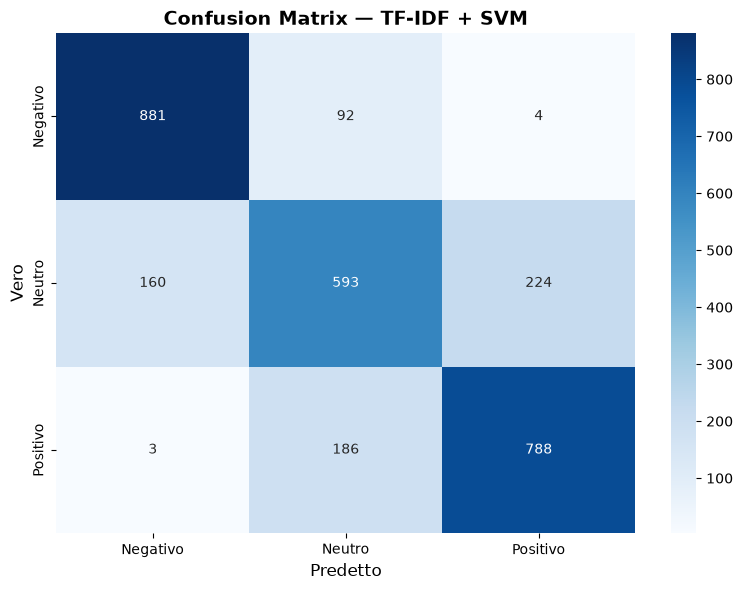

In [6]:
# Predizioni SVM
y_pred_svm = svm_model.predict(X_test_combined)

# Metriche SVM
print_classification_metrics(y[test_idx], y_pred_svm, model_name="TF-IDF + SVM")

# Confusion Matrix SVM
plot_confusion_matrix(
    y[test_idx], y_pred_svm, 
    model_name="TF-IDF + SVM",
    save_path="../results/figures/cm_svm.png"
)

## 5. Modello 2: XGBoost Classifier

In [7]:
print("Training XGBoost in corso (può richiedere 1-2 minuti)...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_combined, y[train_idx])
print("✅ Modello XGBoost addestrato!")

Training XGBoost in corso (può richiedere 1-2 minuti)...


c:\Users\frape\Desktop\UNISA\NLP\ReactNLP\NLP-REACT\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:03:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Modello XGBoost addestrato!



📊 Risultati: TF-IDF + XGBoost

Accuracy:  0.7892
F1 Macro:  0.7802
F1 Weight: 0.7802

              precision    recall  f1-score   support

    Negativo       0.86      0.99      0.92       977
      Neutro       0.74      0.57      0.64       977
    Positivo       0.75      0.81      0.78       977

    accuracy                           0.79      2931
   macro avg       0.78      0.79      0.78      2931
weighted avg       0.78      0.79      0.78      2931

💾 Confusion matrix salvata in: ../results/figures/cm_xgb.png


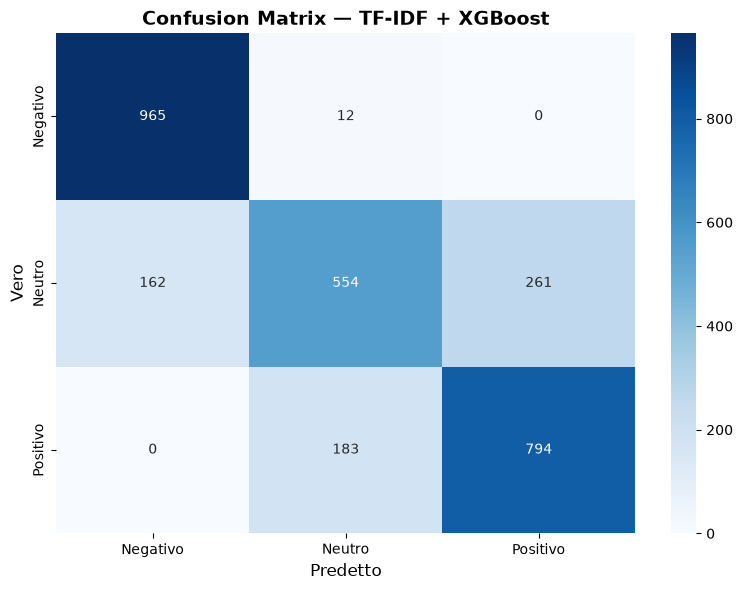

In [8]:
# Predizioni XGBoost
y_pred_xgb = xgb_model.predict(X_test_combined)

# Metriche XGBoost
print_classification_metrics(y[test_idx], y_pred_xgb, model_name="TF-IDF + XGBoost")

# Confusion Matrix XGBoost
plot_confusion_matrix(
    y[test_idx], y_pred_xgb, 
    model_name="TF-IDF + XGBoost",
    save_path="../results/figures/cm_xgb.png"
)

## 6. Salvataggio modelli e metriche

In [9]:
# Crea directory se non esistono
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Salva oggetti per inferenza/explainability futura
joblib.dump(vectorizer, "../models/vectorizer.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(svm_model, "../models/svm_model.pkl")
joblib.dump(xgb_model, "../models/xgb_model.pkl")

print("💾 Modelli e vettorizzatori salvati correttamente in: ../models/")

💾 Modelli e vettorizzatori salvati correttamente in: ../models/


In [10]:
# Raccogli e salva metriche per il confronto nel notebook 05
svm_metrics = get_metrics_dict(y[test_idx], y_pred_svm, model_name="TF-IDF + SVM")
xgb_metrics = get_metrics_dict(y[test_idx], y_pred_xgb, model_name="TF-IDF + XGBoost")

metrics_list = [svm_metrics, xgb_metrics]
with open("../results/baseline_metrics.json", "w") as f:
    json.dump(metrics_list, f, indent=2)

print("💾 Metriche salvate correttamente in: ../results/baseline_metrics.json")

💾 Metriche salvate correttamente in: ../results/baseline_metrics.json
